# Ejercicio 6 - Práctica 6 - Parte 2

El dataset `auto.xlsx` contiene información sobre 392 autos de distintas marcas y modelos. Entre las características registradas se encuentran: el consumo en millas por galón (`mpg`), caballos de fuerza (`horsepower`), peso en libras (`weight`) y la marca y el modelo (`name`).

1. ¿Qué porcentaje de los autos del dataset pertenecen a la marca Ford?

2. Realice un gráfico que le permita visualizar la distribución de los autos del dataset en función de su origen. Para ello, tenga en cuenta que dicha información se encuentra en la columna `origin`, codificada de la siguiente manera: 1 = americano, 2 = europeo y 3 = japonés.

3. Ajuste un modelo de regresión lineal simple considerando al consumo del vehículo como la variable respuesta y a los caballos de fuerza como único predictor. En base a los resultados obtenidos responda:

    1. ¿La relación entre la variable respuesta y la explicativa es positiva o negativa?

    2. ¿Cómo interpreta el valor del coeficiente correspondiente a la variable horsepower?

    3. ¿Qué porcentaje de la variabilidad en el consumo de los vehículos es explicada por el modelo de regresión que ajustó?

4. Realice un gráfico para visualizar la relación que existe entre las variables mpg y horsepower en el dataset y represente sobre el mismo el ajuste realizado en el ítem anterior. ¿Encuentra alguna falencia o limitación en el modelo propuesto? Justifique

5. Si su respuesta al ítem fue afirmativa, ¿cómo podría mejorar el modelo para resolver las limitaciones o falencias encontradas?

## Cargamos el dataset

In [31]:
# Importamos librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
from scipy.stats import norm, kurtosis
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from scipy.stats import chi2

In [32]:
data = pd.read_excel('../../datasets/auto.xlsx')
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [33]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    str    
dtypes: float64(3), int64(5), str(1)
memory usage: 27.7 KB


## Ítem 1

¿Qué porcentaje de los autos del dataset pertenecen a la marca Ford?

In [34]:
# Obtenemos los registros identificando los registros cuyo nombre comienza con "ford".

data["marca"] = data["name"].str.split().str[0]
porcentaje_ford = (data["marca"].str.lower() == "ford").mean()*100
print(f"El porcentaje de registros que corresponden a la marca Ford es: {porcentaje_ford:.2f}%")

El porcentaje de registros que corresponden a la marca Ford es: 12.24%


# Ítem 2

Realice un gráfico que le permita visualizar la distribución de los autos del dataset en función de su origen. Para ello, tenga en cuenta que dicha información se encuentra en la columna `origin`, codificada de la siguiente manera: 1= americano, 2 = europeo y 3 = japonés.

In [35]:
print(data["origin"].dtype)
print(data["origin"].unique())

int64
[1 3 2]


In [36]:
data["origin"] = data["origin"].map({
    1: "americano",
    2: "europeo",
    3: "japonés"
})

data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,marca
0,18.0,8,307.0,130,3504,12.0,70,americano,chevrolet chevelle malibu,chevrolet
1,15.0,8,350.0,165,3693,11.5,70,americano,buick skylark 320,buick
2,18.0,8,318.0,150,3436,11.0,70,americano,plymouth satellite,plymouth
3,16.0,8,304.0,150,3433,12.0,70,americano,amc rebel sst,amc
4,17.0,8,302.0,140,3449,10.5,70,americano,ford torino,ford


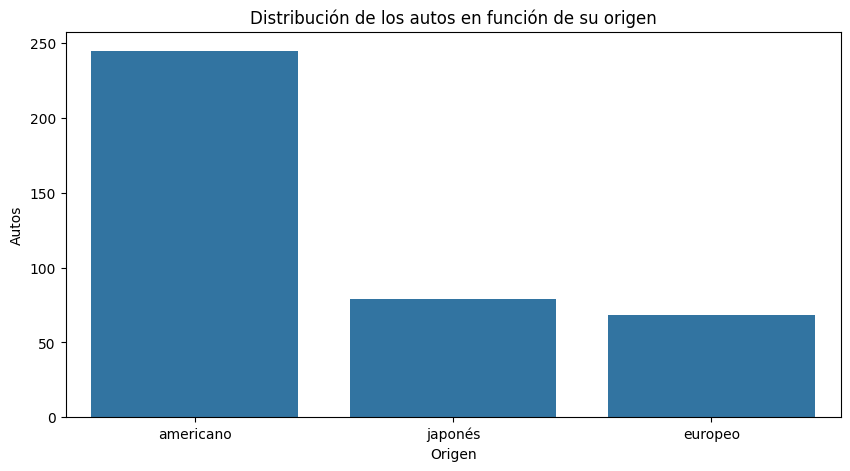

In [37]:
plt.figure(figsize=(10,5))

sns.countplot(data=data, x="origin")
plt.title("Distribución de los autos en función de su origen")
plt.xlabel("Origen")
plt.ylabel("Autos")
plt.show()


## Ítem 3

Ajuste un modelo de regresión lineal simple considerando al consumo del vehículo como la variable respuesta y a los caballos de fuerza como único predictor. En base a los resultados obtenidos responda:

1. ¿La relación entre la variable respuesta y la explicativa es positiva o negativa?
2. ¿Cómo interpreta el valor del coeficiente correspondiente a la variable `horsepower`?
3. ¿Qué porcentaje de la variabilidad en el consumo de los vehículos es explicada por el modelo de regresión que ajustó?


Consideremos el modelo

$$Y = \beta_0 + \beta_1X$$

donde $X$ son los caballos de fuerza.

In [46]:
modelo = smf.ols(
    formula = 'mpg ~ horsepower',
    data = data).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Sun, 07 Jun 2026   Prob (F-statistic):           7.03e-81
Time:                        16:12:29   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.9359      0.717     55.660      0.0

Reemplazando los coeficientes, el modelo es

$$Y = 39.9359 - 0.1578X.$$

1. Observamos que la relación en negativa. Es decir, los vehículos con mayor potencia tienden a tener menor rendimiento en millas por galón.
2. Por cada caballo de fuerza adicional, el consumo esperado disminuye 0.1578 millas por galón.
3. Tenemos que $R^2 = 0.606$. Entonces, el modelo explica el 60.6% de la variabilidad observada en el consumo de los vehículos.

# Ítem 4

Realice un gráfico para visualizar la relación que existe entre las variables mpg y horsepower en el dataset y represente sobre el mismo el ajuste realizado en el ítem anterior. ¿Encuentra alguna falencia o limitación en el modelo propuesto? Justifique

In [40]:
data['predichos'] = modelo.predict(data)
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,marca,predichos
0,18.0,8,307.0,130,3504,12.0,70,americano,chevrolet chevelle malibu,chevrolet,19.416046
1,15.0,8,350.0,165,3693,11.5,70,americano,buick skylark 320,buick,13.891480
2,18.0,8,318.0,150,3436,11.0,70,americano,plymouth satellite,plymouth,16.259151
3,16.0,8,304.0,150,3433,12.0,70,americano,amc rebel sst,amc,16.259151
4,17.0,8,302.0,140,3449,10.5,70,americano,ford torino,ford,17.837598


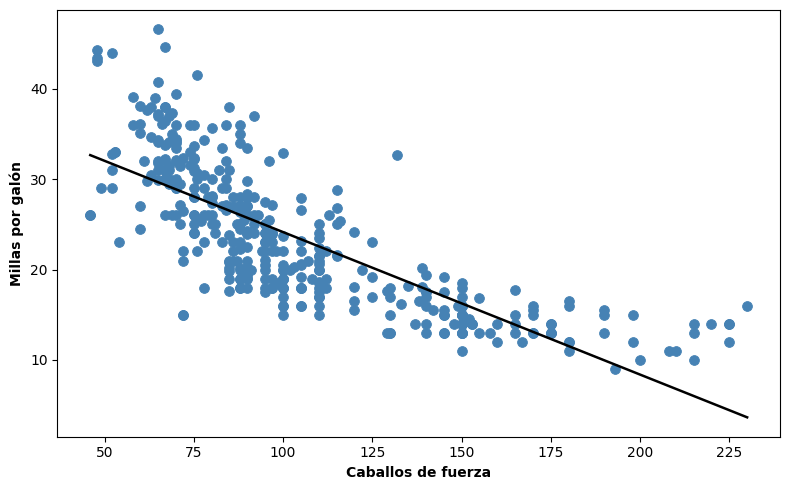

In [42]:
fig, ax = plt.subplots(figsize = (8, 5))

sns.scatterplot(x = 'horsepower', y = 'mpg', data = data,
                color = 'steelblue', edgecolor = 'steelblue', 
                s = 50, ax = ax)
sns.lineplot(x = 'horsepower', y = 'predichos', data = data,
                color = 'black', linewidth = 1.8, ax = ax)

ax.set_xlabel('Caballos de fuerza', fontweight = 'bold')
ax.set_ylabel('Millas por galón', fontweight = 'bold')

plt.tight_layout()
plt.show()

El gráfico muestra una clara relación negativa entre los caballos de fuerza y el rendimiento en millas por galón. Sin embargo, la nube de puntos sugiere que la relación no es estrictamente lineal, observándose cierta curvatura y una dispersión variable de las observaciones. Por lo tanto, el modelo lineal simple presenta limitaciones para describir completamente la relación entre ambas variables.

## Ítem 5

Si su respuesta al ítem fue afirmativa, ¿cómo podría mejorar el modelo para resolver las limitaciones o falencias encontradas?

Una posible mejora consiste en incorporar otras variables explicativas relevantes, como el peso del vehículo (`weight`), mediante un modelo de regresión múltiple.

Para esto, proponemos el modelo

$$Y = \beta_0 + \beta_1X_h + \beta_2 X_w$$

donde
- $X_h$ son los caballos de fuerza, y
- $X_w$ es el peso de vehículo.

In [43]:
modelo2 = smf.ols(formula = 'mpg ~ horsepower + weight', data = data).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     467.9
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          3.06e-104
Time:                        15:30:04   Log-Likelihood:                -1121.0
No. Observations:                 392   AIC:                             2248.
Df Residuals:                     389   BIC:                             2260.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     45.6402      0.793     57.540      0.0

Obtenemos el modelo 

$$Y = 45.6402 - 0.0473 X_h - 0.0058 X_w,$$

El modelo tine un $R^2$ ajustado de $0.705$, lo que indica que aproximadamente el 70.5% de la variabilidad observada en el consumo (mpg) es explicada por los caballos de fuerza y el peso del vehículo.

Este valor es superior al obtenido con el modelo de regresión lineal simple, por lo que la incorporación de la variable peso mejora la capacidad explicativa y predictiva del modelo.